In [127]:

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score,classification_report,accuracy_score

In [128]:
raw_data_url="https://gist.githubusercontent.com/anu-006/62e09c272b3e7b9b242bb9543fc74c2f/raw/8f88c0c6a152a1e38aaab48779cdf70fdce463bd/milknew.csv"

In [129]:
data=pd.read_csv(raw_data_url)
data

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium
...,...,...,...,...,...,...,...,...
1054,6.7,45,1,1,0,0,247,medium
1055,6.7,38,1,0,1,0,255,high
1056,3.0,40,1,1,1,1,255,low
1057,6.8,43,1,0,1,0,250,high


In [130]:
data.shape

(1059, 8)

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


In [132]:
(data.isnull().sum()/len(data))*100

,0
pH,0.0
Temprature,0.0
Taste,0.0
Odor,0.0
Fat,0.0
Turbidity,0.0
Colour,0.0
Grade,0.0


In [133]:
data.describe()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,0.546742,0.432483,0.671388,0.491029,251.840415
std,1.399679,10.098364,0.498046,0.495655,0.469930,0.500156,4.307424
min,3.000000,34.000000,0.000000,0.000000,0.000000,0.000000,240.000000
25%,6.500000,38.000000,0.000000,0.000000,0.000000,0.000000,250.000000
50%,6.700000,41.000000,1.000000,0.000000,1.000000,0.000000,255.000000
75%,6.800000,45.000000,1.000000,1.000000,1.000000,1.000000,255.000000
max,9.500000,90.000000,1.000000,1.000000,1.000000,1.000000,255.000000


In [134]:
Corr=data.corr(numeric_only=True)

In [135]:
num=data.drop(columns=['Grade'])

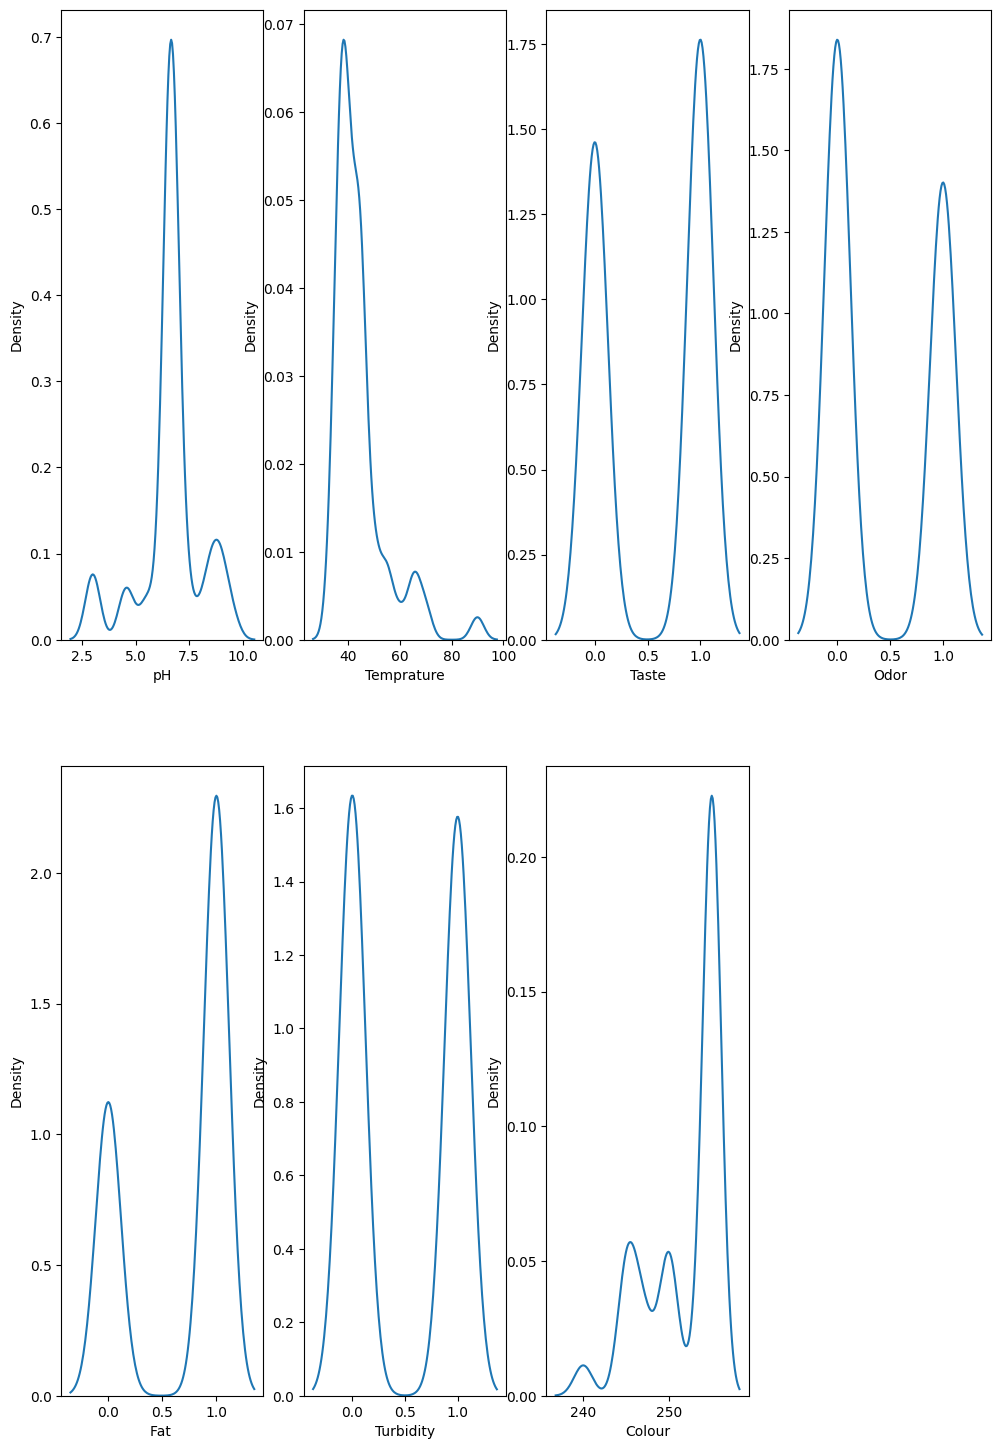

In [136]:
plt.figure(figsize=(12,18))

for index,col in enumerate(num):
  plt.subplot(2,4,index+1)
  sns.kdeplot(data[col])

In [137]:
for i in num:
 print(f'{i} : ',data[i].skew())

pH :  -0.6839041087967945
Temprature :  2.2167391370684855
Taste :  -0.18805770016624745
Odor :  0.2729492397886804
Fat  :  -0.7307991428407
Turbidity :  0.03593961108424127
Colour :  -1.024901531279754


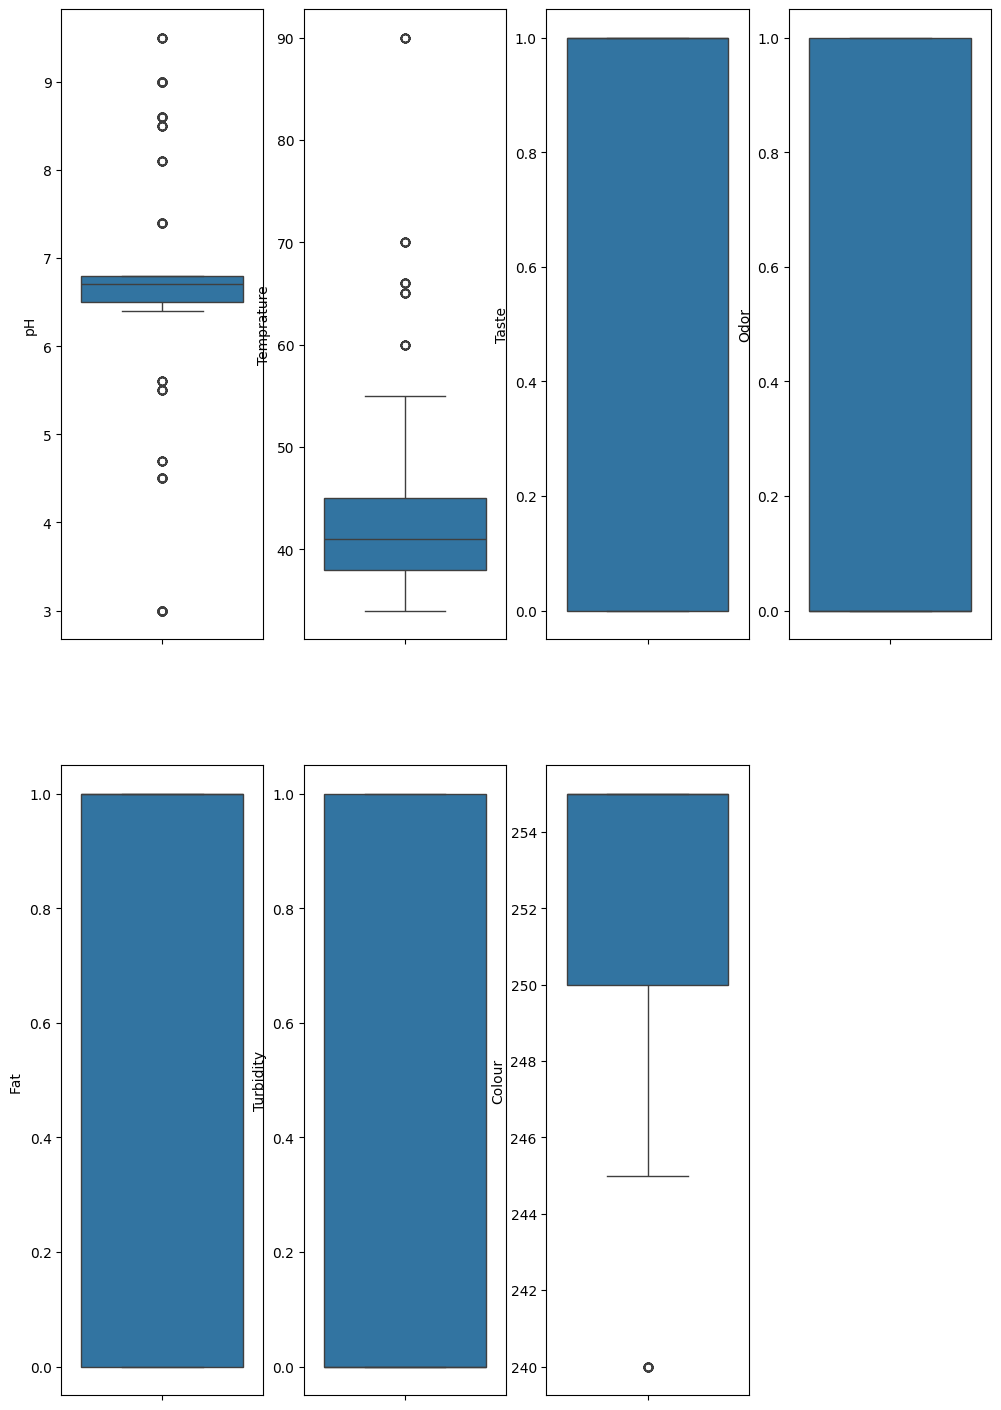

In [138]:
plt.figure(figsize=(12,18))

for index,col in enumerate(num):
  plt.subplot(2,4,index+1)
  sns.boxplot(data[col])

In [139]:
from sklearn.model_selection import train_test_split

X = data.drop('Grade', axis=1)
y = data['Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()

# Encode the target variable 'Grade' directly
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [140]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

Now, let's fit the pipeline to the training data and make predictions.


--- Evaluating logistic Regression ---
Accuracy: 0.7075

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        48
           1       0.67      0.76      0.71        78
           2       0.83      0.78      0.80        86

    accuracy                           0.71       212
   macro avg       0.69      0.68      0.68       212
weighted avg       0.71      0.71      0.71       212

ROC AUC (OVR, Weighted): 0.9101

--- Evaluating Decision Tree ---
Accuracy: 0.9906

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       1.00      0.99      0.99        78
           2       0.99      1.00      0.99        86

    accuracy                           0.99       212
   macro avg       0.99      0.99      0.99       212
weighted avg       0.99      0.99      0.99       212

ROC AUC (OVR, Weighted): 0.9930

--- Evaluating Ra

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Accuracy: 0.9953

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.99      0.99        78
           2       1.00      1.00      1.00        86

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212

ROC AUC (OVR, Weighted): 1.0000

--- Evaluating SVC ---
Accuracy: 0.9151

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84        48
           1       1.00      0.95      0.97        78
           2       0.95      0.87      0.91        86

    accuracy                           0.92       212
   macro avg       0.90      0.92      0.91       212
weighted avg       0.93      0.92      0.92       212

ROC AUC (OVR, Weighted): 0.9949

--- Evaluating XGBoost ---
Accuracy: 0.9906

Classification Report:

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


ROC AUC (OVR, Weighted): 0.9998

--- Evaluating Gradient Boosting ---
Accuracy: 0.9953

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      0.99      0.99        78
           2       0.99      1.00      0.99        86

    accuracy                           1.00       212
   macro avg       1.00      1.00      1.00       212
weighted avg       1.00      1.00      1.00       212

ROC AUC (OVR, Weighted): 0.9999


/tmp/ipykernel_1482/838330516.py:66: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Random (AUC = 0.50)')


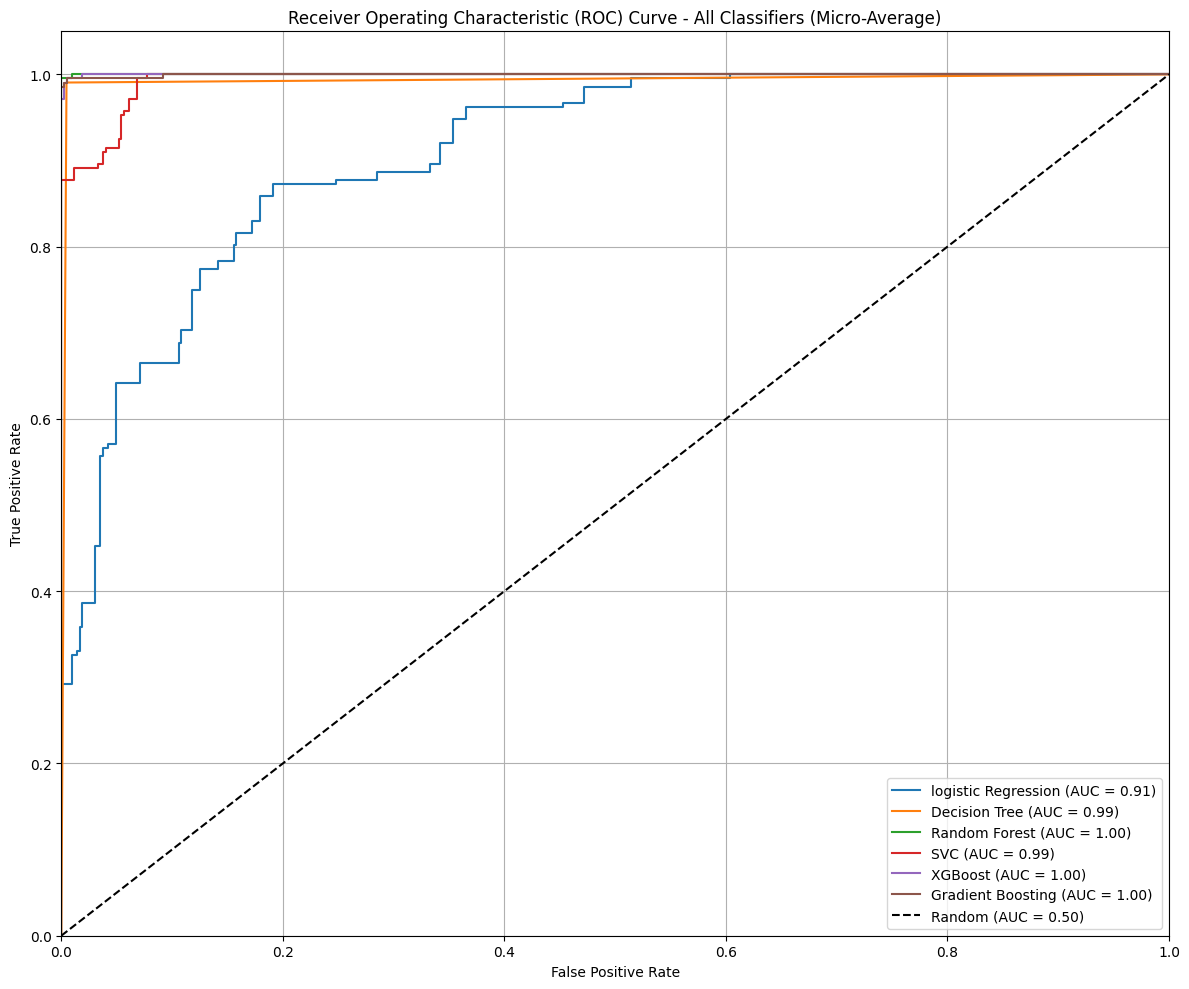

In [141]:
from sklearn.metrics import roc_curve, auc

classifiers = {
    'logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(random_state=42, probability=True), # probability=True is needed for some metrics like ROC
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'), # 'use_label_encoder' parameter is deprecated and removed
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
roc_data_for_plot = [] # List to store data for combined ROC plot

# Binarize y_test once for multi-class ROC plotting
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)

for name, classifier in classifiers.items():
    print(f"\n--- Evaluating {name} ---")
    # Create a new pipeline for each classifier, keeping PowerTransformer
    pipeline_clf = Pipeline([
        ('skew', PowerTransformer()),
        (name, classifier)
    ])

    # Fit the pipeline
    pipeline_clf.fit(X_train, y_train)

    # Make predictions
    y_pred_clf = pipeline_clf.predict(X_test)

    # Evaluate the model
    accuracy_clf = accuracy_score(y_test, y_pred_clf)
    print(f"Accuracy: {accuracy_clf:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_clf))

    results[name] = {
        'accuracy': accuracy_clf,
        'classification_report': classification_report(y_test, y_pred_clf, output_dict=True)
    }


    if hasattr(pipeline_clf.named_steps[name], 'predict_proba'):
        y_pred_proba_clf = pipeline_clf.predict_proba(X_test)


        roc_auc_ovr = roc_auc_score(y_test, y_pred_proba_clf, multi_class='ovr', average='weighted')
        print(f"ROC AUC (OVR, Weighted): {roc_auc_ovr:.4f}")
        results[name]['roc_auc'] = roc_auc_ovr


        fpr_micro, tpr_micro, _ = roc_curve(y_test_binarized.ravel(), y_pred_proba_clf.ravel())
        roc_auc_micro = auc(fpr_micro, tpr_micro)
        roc_data_for_plot.append({'name': name, 'fpr': fpr_micro, 'tpr': tpr_micro, 'roc_auc': roc_auc_micro})
    else:
        print(f"Classifier {name} does not support probability predictions. ROC AUC and curve cannot be calculated.")

plt.figure(figsize=(12, 10))

for data_item in roc_data_for_plot:
    plt.plot(data_item['fpr'], data_item['tpr'], label=f"{data_item['name']} (AUC = {data_item['roc_auc']:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - All Classifiers (Micro-Average)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

XGBoost is performing better than other models